In [1]:
from profiling_and_attack import mlp_eshard, information, cnn, mlp

from sklearn.preprocessing import StandardScaler
from utils import *
from tensorflow.keras import Model
from tensorflow.keras.utils import to_categorical
from sklearn.decomposition import PCA
import sys
from matplotlib import pyplot as plt

2025-01-29 16:34:11.712985: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-29 16:34:11.733083: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-29 16:34:11.733119: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-29 16:34:11.733832: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-29 16:34:11.737804: I tensorflow/core/platform/cpu_feature_guar

In [2]:
import tensorflow as tf

def train_linear_probe(x_train, y_train, epochs=5):
    """
    Defines and trains a linear probe with a dense layer on top of extracted features.
    
    Args:
        x_train (np.array or tf.Tensor): Training features.
        y_train (np.array or tf.Tensor): Training labels.
        
    Returns:
        tf.keras.Model: Trained linear probe model.
    """
    # Define the linear probe model (a simple dense layer on the input features)
    num_classes = len(set(y_train))  # Infer number of classes from labels
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=x_train.shape[1:]),  # Input shape based on feature size
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    # Compile the model
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    # Train the linear probe
    model.fit(x_train, y_train, epochs=epochs, batch_size=200)

    return model

def train_non_linear_probe(x_train, y_train, epochs=5):
    """
    Defines and trains a linear probe with a dense layer on top of extracted features.
    
    Args:
        x_train (np.array or tf.Tensor): Training features.
        y_train (np.array or tf.Tensor): Training labels.
        
    Returns:
        tf.keras.Model: Trained linear probe model.
    """
    # Define the linear probe model (a simple dense layer on the input features)
    num_classes = len(set(y_train))  # Infer number of classes from labels
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=x_train.shape[1:]),  # Input shape based on feature size
        tf.keras.layers.Dense(10, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    # Compile the model
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    # Train the linear probe
    model.fit(x_train, y_train, epochs=epochs, batch_size=200)

    return model

In [3]:
dataset_id = 'ascad-variable'
resample_window=80
traces_dim = 2000
model = mlp(256,traces_dim)
n_prof= 100000

def hw(input):

    result = np.zeros_like(input)
    for i in range(8):
        result += (input >> i) & 0x1
    return result


lm = "ID"
target_byte = 2
path = "/mnt/d/Datasets"
dataset = load_dataset(dataset_id, path, target_byte, traces_dim, leakage_model=lm, n_prof=n_prof)
pi_og, pi_patch_new, pi_patch_og = [], [], []
dataset.x_profiling, dataset.x_attack = scale_dataset(dataset.x_profiling, dataset.x_attack, StandardScaler())


Model: "mlp_softmax"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 2000)]            0         
                                                                 
 dense (Dense)               (None, 100)               200100    
                                                                 
 dense_1 (Dense)             (None, 100)               10100     
                                                                 
 dense_2 (Dense)             (None, 100)               10100     
                                                                 
 dense_3 (Dense)             (None, 100)               10100     
                                                                 
 dense_4 (Dense)             (None, 100)               10100     
                                                                 
 dense_5 (Dense)             (None, 100)               

2025-01-29 16:34:15.714934: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-29 16:34:15.731011: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-29 16:34:15.731056: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-29 16:34:15.732849: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-29 16:34:15.732885: I external/local_xla/xla/stream_executor

In [4]:
def reload_model(epoch= 10, layers=1):
    global layer, model, tmp, tmp_att
    #layer = layers
    model.load_weights(f"model_checkpoints/mlp_ascadr_{epoch:02d}.weights.h5")
    outputs = [model.layers[layer].output for layer in range(0, len(model.layers))]
    new_model = Model(model.inputs, outputs)
    tmp =  new_model.predict(dataset.x_profiling)
    #print(tmp.shape)
    tmp_att = new_model.predict(dataset.x_attack).copy()
sbox_ins = (dataset.profiling_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.profiling_keys[:, dataset.target_byte].astype(np.uint8))
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))

probes_for_bit = []

layer_out = 5
def retrain_probes_per_bit(epochs=5):
    global probes_for_bit 
    probes_for_bit = []
    for k in range(2):

        probe_for_sbox_input = train_linear_probe(tmp[layer_out],(dataset.profiling_labels.astype(np.uint8)>>k)&0x1, epochs=epochs)
        probes_for_bit.append(probe_for_sbox_input)

    for k in range(2):

        probe_for_sbox_input = train_linear_probe(tmp[layer_out],(sbox_ins>>k)&0x1, epochs=epochs)
        probes_for_bit.append(probe_for_sbox_input)
    
def probe_accuracies():
    probe_accuracies = []
    for k in range(8):

        bit_points = (dataset.attack_labels.astype(np.uint8)>>k)&0x1
        probe_accuracies.append(np.sum(np.argmax(probes_for_bit[k].predict(tmp_att[layer_out][:10000]), axis=1) ==bit_points)/10000)

    for k in range(8):

        bit_points = (sbox_ins_att>>k)&0x1
        probe_accuracies.append(np.sum(np.argmax(probes_for_bit[k+8].predict(tmp_att[layer_out][:10000]), axis=1) ==bit_points)/10000)
    print(probe_accuracies)
    return np.array(probe_accuracies)
def only_reload(epoch=10):
    model.load_weights(f"model_checkpoints/mlp_ascadr_{epoch:02d}.weights.h5")

In [30]:

# #import os
# #os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
# probe_total = np.zeros((100, 16))
# import gc
# gc.collect()
# for i in range(1, 101):
#     reload_model(i)
    
#     # pi_prof.append(information(model.predict(dataset.x_profiling[:10000]), dataset.profiling_labels[:10000], 256))
#     # pi_list.append(information(model.predict(dataset.x_attack[:10000]), dataset.attack_labels[:10000], 256))
#     retrain_probes_per_bit(epochs=2)
#     probe_total[i-1] = probe_accuracies()
#     gc.collect()
    

313/313 [==============================] - 0s 1ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.5001
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.5010
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.5002
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.5013
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6933 - accuracy: 0.4993
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.4983
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.5015
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.5011
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6933 - accuracy: 0.4986
Epoch 2/2
250/250 [==============================] - 0

313/313 [==============================] - 0s 1ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6933 - accuracy: 0.4974
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.4993
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.5018
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.5003
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6933 - accuracy: 0.5003
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6933 - accuracy: 0.4996
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6933 - accuracy: 0.4995
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.5006
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6933 - accuracy: 0.4963
Epoch 2/2
250/250 [==============================] - 0

313/313 [==============================] - 1s 1ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6933 - accuracy: 0.4971
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.5013
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6933 - accuracy: 0.5016
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.5010
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.4989
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.5004
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.5005
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.5032
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6933 - accuracy: 0.4989
Epoch 2/2
250/250 [==============================] - 0

313/313 [==============================] - 0s 1ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6934 - accuracy: 0.4995
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.5033
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6934 - accuracy: 0.4996
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.5003
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6933 - accuracy: 0.4992
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.4984
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.5002
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.5029
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6933 - accuracy: 0.5002
Epoch 2/2
250/250 [==============================] - 0

313/313 [==============================] - 1s 2ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6934 - accuracy: 0.4948
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.5016
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6935 - accuracy: 0.4989
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.5003
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6932 - accuracy: 0.5021
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.4999
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6933 - accuracy: 0.4997
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6932 - accuracy: 0.5016
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6934 - accuracy: 0.5001
Epoch 2/2
250/250 [==============================] - 0

...

313/313 [==============================] - 0s 1ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.3546 - accuracy: 0.8349
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.2562 - accuracy: 0.8784
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.5645 - accuracy: 0.7316
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.3805 - accuracy: 0.8207
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.9766 - accuracy: 0.5324
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6968 - accuracy: 0.5705
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.8970 - accuracy: 0.5286
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6833 - accuracy: 0.5765
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.8481 - accuracy: 0.5440
Epoch 2/2
250/250 [==============================] - 0

313/313 [==============================] - 0s 1ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.4151 - accuracy: 0.8049
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.2697 - accuracy: 0.8714
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.7805 - accuracy: 0.6798
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.4150 - accuracy: 0.8045
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.9800 - accuracy: 0.5338
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6944 - accuracy: 0.5720
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.9050 - accuracy: 0.5389
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6825 - accuracy: 0.5792
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.9359 - accuracy: 0.5251
Epoch 2/2
250/250 [==============================] - 0

313/313 [==============================] - 0s 1ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.5050 - accuracy: 0.7912
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.2804 - accuracy: 0.8658
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.5347 - accuracy: 0.7678
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.3596 - accuracy: 0.8335
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.9303 - accuracy: 0.5361
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.7009 - accuracy: 0.5712
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.9022 - accuracy: 0.5410
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6894 - accuracy: 0.5757
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.8627 - accuracy: 0.5361
Epoch 2/2
250/250 [==============================] - 0

313/313 [==============================] - 1s 2ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.5852 - accuracy: 0.7704
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.2808 - accuracy: 0.8668
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6511 - accuracy: 0.7219
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.3849 - accuracy: 0.8180
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.8915 - accuracy: 0.5554
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6779 - accuracy: 0.5839
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.9356 - accuracy: 0.5378
Epoch 2/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6862 - accuracy: 0.5730
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.8592 - accuracy: 0.5383
Epoch 2/2
250/250 [==============================] - 0

313/313 [==============================] - 0s 1ms/step
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.6007 - accuracy: 0.7659
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.2897 - accuracy: 0.8644
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.5672 - accuracy: 0.7402
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.3850 - accuracy: 0.8199
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.8574 - accuracy: 0.5440
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6827 - accuracy: 0.5786
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.9201 - accuracy: 0.5424
Epoch 2/2
250/250 [==============================] - 0s 2ms/step - loss: 0.6854 - accuracy: 0.5771
Epoch 1/2
250/250 [==============================] - 1s 2ms/step - loss: 0.9174 - accuracy: 0.5438
Epoch 2/2
250/250 [==============================] - 0

0


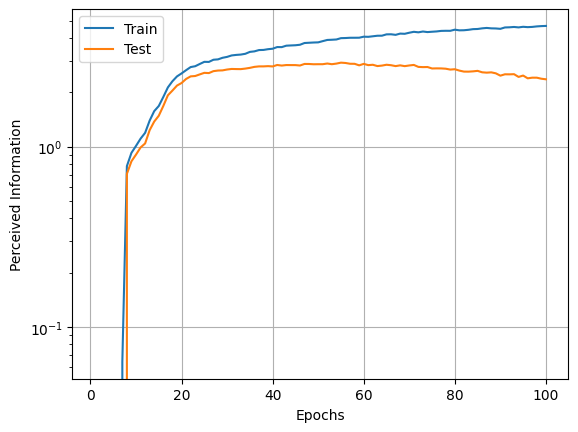

[[0.5005 0.499  0.5021 ... 0.4935 0.4995 0.5041]
 [0.5046 0.4959 0.495  ... 0.4994 0.5062 0.5016]
 [0.4989 0.5033 0.4939 ... 0.4986 0.4967 0.5032]
 ...
 [0.8253 0.7843 0.5712 ... 0.562  0.5471 0.5659]
 [0.8239 0.7825 0.5805 ... 0.5649 0.5586 0.562 ]
 [0.8265 0.7826 0.5663 ... 0.5657 0.5602 0.5709]]


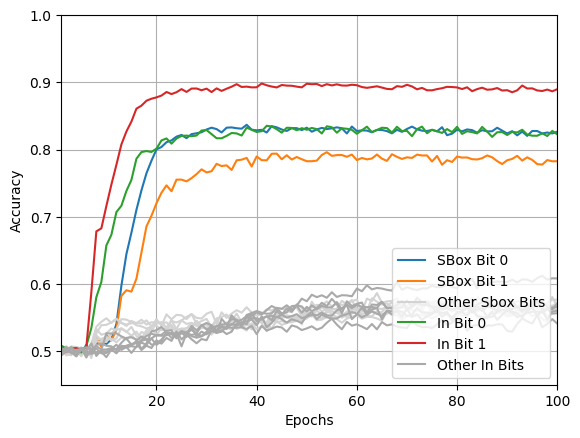

In [36]:
for i in range(100):
    if probe_total[i, 1] > 0:
        print(i)
        break 

plt.plot(range(1, 101), pi_prof, label="Train")
plt.plot(range(1, 101), pi_list, label="Test")


plt.yscale('log')
plt.xlabel("Epochs")
plt.ylabel("Perceived Information")
plt.grid()
plt.legend()
plt.savefig("PI_ascadr.png", dpi=400)
plt.show()
plt.close()
print(probe_total)
for i in range(16):
    if i % 8 < 2:
        if i > 7:
            plt.plot(range(1, 101), probe_total[:, i], label=f"In Bit {i%8}")
        else:
            plt.plot(range(1, 101), probe_total[:, i], label=f"SBox Bit {i%8}")
    
    else:
        if i ==2:
            plt.plot(range(1, 101), probe_total[:, i], color='lightgrey', label="Other Sbox Bits")
        elif i < 8:
            plt.plot(range(1, 101), probe_total[:, i], color='lightgrey')
        elif i == 10:
            plt.plot(range(1, 101), probe_total[:, i], color='darkgrey', label="Other In Bits")
        else:
            plt.plot(range(1, 101), probe_total[:, i], color='darkgrey')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim([0.45, 1.0])
plt.grid()
plt.xlim([1, 100])
plt.legend(loc=4)
plt.savefig("acc_bits_ascad.png", dpi=400)
plt.show()
plt.close()
np.savez("ascadr_pi_and_acc.npz", pi_list=pi_list, pi_prof=pi_prof, probe_total=probe_total)

[[0.5005 0.499  0.5021 ... 0.4935 0.4995 0.5041]
 [0.5046 0.4959 0.495  ... 0.4994 0.5062 0.5016]
 [0.4989 0.5033 0.4939 ... 0.4986 0.4967 0.5032]
 ...
 [0.8253 0.7843 0.5712 ... 0.562  0.5471 0.5659]
 [0.8239 0.7825 0.5805 ... 0.5649 0.5586 0.562 ]
 [0.8265 0.7826 0.5663 ... 0.5657 0.5602 0.5709]]


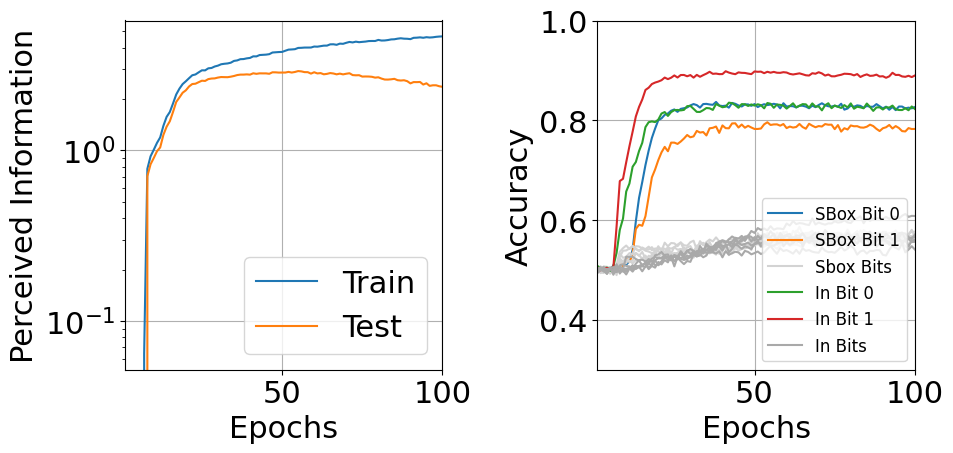

In [27]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22

dict_np = np.load("ascadr_pi_and_acc.npz", allow_pickle=True)#, pi_list=pi_list, pi_prof=pi_prof, probe_total=probe_total)
pi_list = dict_np["pi_list"]
pi_prof = dict_np["pi_prof"]
probe_total = dict_np["probe_total"]
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.plot(range(1, 101), pi_prof, label="Train")
plt.plot(range(1, 101), pi_list, label="Test")


plt.yscale('log')
plt.xlabel("Epochs")
plt.ylabel("Perceived Information")
plt.xlim([1,100])
plt.grid()
plt.legend()
plt.subplot(1,2,2)
print(probe_total)
for i in range(16):
    if i % 8 < 2:
        if i > 7:
            plt.plot(range(1, 101), probe_total[:, i], label=f"In Bit {i%8}")
        else:
            plt.plot(range(1, 101), probe_total[:, i], label=f"SBox Bit {i%8}")
    
    else:
        if i ==2:
            plt.plot(range(1, 101), probe_total[:, i], color='lightgrey', label="Sbox Bits")
        elif i < 8:
            plt.plot(range(1, 101), probe_total[:, i], color='lightgrey')
        elif i == 10:
            plt.plot(range(1, 101), probe_total[:, i], color='darkgrey', label="In Bits")
        else:
            plt.plot(range(1, 101), probe_total[:, i], color='darkgrey')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim([0.3, 1.0])
plt.grid()
plt.xlim([1, 100])
plt.legend(loc=4, prop={'size': 12})
plt.tight_layout()
plt.savefig("ascad_pi_acc.png", dpi=100)


In [19]:
print(len(pi_prof))

100


In [67]:
def plot_gradient(in_var, probe,  labels ,inter_model = None):
    in_neurons = tf.Variable(in_var)
    with tf.GradientTape() as tape:
        if inter_model is None:
            inter = in_neurons
        else:
            inter = inter_model(in_neurons)
        predicts = probe(inter, training=False)
    
        loss = tf.keras.losses.CategoricalCrossentropy()(predicts, tf.keras.utils.to_categorical(labels))

    grads = tape.gradient(loss, in_neurons)
    dgrad_abs = tf.math.abs(grads)

    inf_score = np.sum(dgrad_abs.numpy(), axis=0)
    most_imp_neurons = np.where(inf_score> np.mean(inf_score) + 0*np.std(inf_score))[0]
    #print(inf_score)
    plt.scatter(most_imp_neurons-0.2, inf_score[most_imp_neurons], color='r')

    plt.plot(inf_score, label=f"Bit")
    plt.show()
    plt.close()
    return inf_score

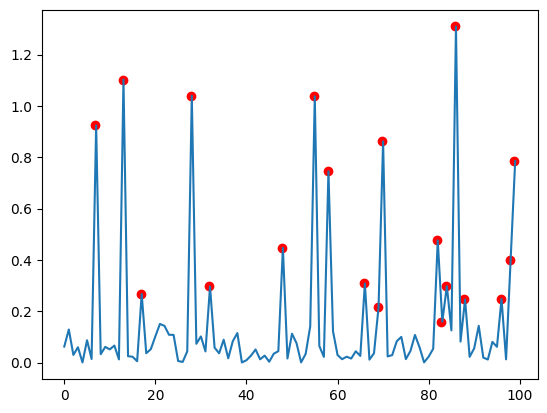

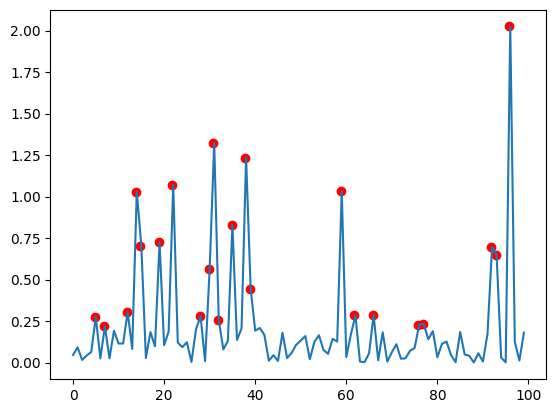

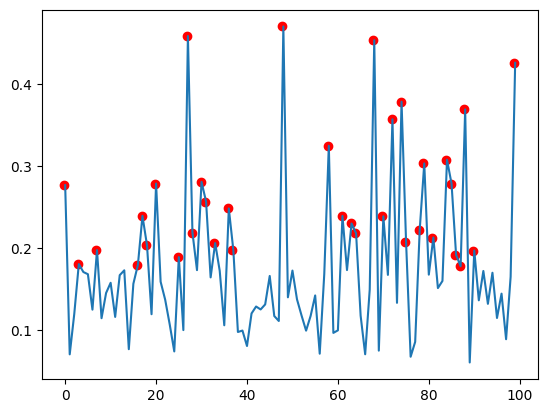

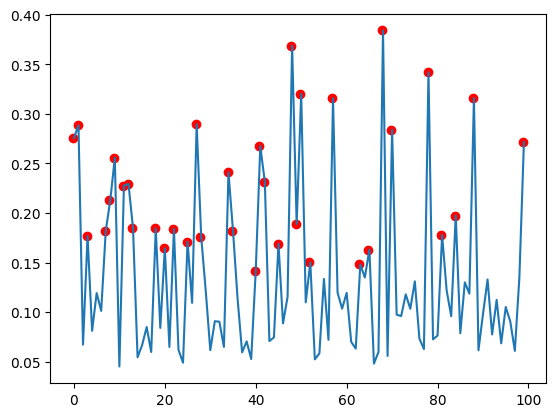

In [66]:
layer=2
model_for_probe =Model(model.layers[layer].input, model.layers[layer].output)

sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))
list_of_grads = []
for k in range(2):
    list_of_grads.append(plot_gradient(tmp_att[layer], probes_for_bit[k], (dataset.attack_labels>>k)&0x1))
non_lin_probes = []        
# non_lin_probes.append(train_non_linear_probe(tmp[1],(sbox_ins>>0)&0x1, epochs=5))
# non_lin_probes.append(train_non_linear_probe(tmp[1],(sbox_ins>>1)&0x1, epochs=5))
for k in range(2):

    list_of_grads.append(plot_gradient(tmp_att[layer-1], probes_for_bit[k+2], (sbox_ins_att>>k)&0x1, model_for_probe))
# for k in range(2):

#     list_of_grads.append(plot_gradient(tmp_att[layer-1], non_lin_probes[k], (sbox_ins_att>>k)&0x1))

In [5]:

# most_imp_neurons = np.argsort(list_of_grads[2])[::-1][:20]
# most_imp_neurons = np.sort(np.union1d( most_imp_neurons, np.argsort(list_of_grads[3])[::-1][:20]))
# most_imp_neurons = np.where(list_of_grads[1] > np.mean(list_of_grads[1]) + 1*np.std(list_of_grads[1]))[0]
# most_imp_neurons = np.sort(np.union1d(most_imp_neurons, np.where(list_of_grads[0] > 1*np.std(list_of_grads[0])+ np.mean(list_of_grads[0]))))
# print(len(most_imp_neurons))
epoch=25
reload_model(epoch)
layer = 2
from sklearn.manifold import TSNE, Isomap
from sklearn.decomposition import KernelPCA, PCA
pca = PCA(n_components=4)

new_s1_prof = pca.fit_transform(tmp[layer][:100000])
new_s1_att = pca.transform(tmp_att[layer])
on = np.where(dataset.attack_labels&0x3==0)
off = np.where(dataset.attack_labels&0x3==1)
on2 = np.where(dataset.attack_labels&0x3==2)
off3 = np.where(dataset.attack_labels&0x3 ==3)
on = np.where(sbox_ins_att&0x3==0)
off = np.where(sbox_ins_att&0x3==1)
on2 = np.where(sbox_ins_att&0x3==2)
off3 = np.where(sbox_ins_att&0x3 ==3)
# on = np.where(sbox_ins[:50000]&0x3==0)
# off = np.where(sbox_ins[:50000]&0x3==1)
# on2 = np.where(sbox_ins[:50000]&0x3==2)
# off3 = np.where(sbox_ins[:50000]&0x3 ==3)
# on = np.where(dataset.attack_labels&0x1==0)
# off = np.where(dataset.attack_labels&0x1==1)
# on2 = np.where((dataset.attack_labels>>1)&0x1==0)
# off3 = np.where((dataset.attack_labels>>1)&0x1 ==1)

in1 = 0
in2 = 1


plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.legend()
plt.title("Bit 0 & 1 of $p_i \oplus k_i$")
plt.savefig(f"pi_ki_epoch_{epoch}_ascad.png", dpi=400)
plt.show()
plt.close()
rin = dataset.share5_attack[target_byte].astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)

plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.legend()
plt.title("Bit 0 & 1 of $r_{in}$")
plt.savefig(f"rin_ascad_epoch_{epoch}.png", dpi=400)
plt.show()
plt.close()
rin = dataset.share6_attack[target_byte].astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)

plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.legend()
plt.title("Bit 0 & 1 of $p_i \oplus k_i \oplus r_{in}$")
plt.savefig(f"pi_ki_ri_epoch_{epoch}_ascad.png", dpi=400)
plt.show()
plt.close()



NameError: name 'tmp' is not defined

78/78 [==============================] - 0s 1ms/step


14/14 [==============================] - 0s 1ms/step


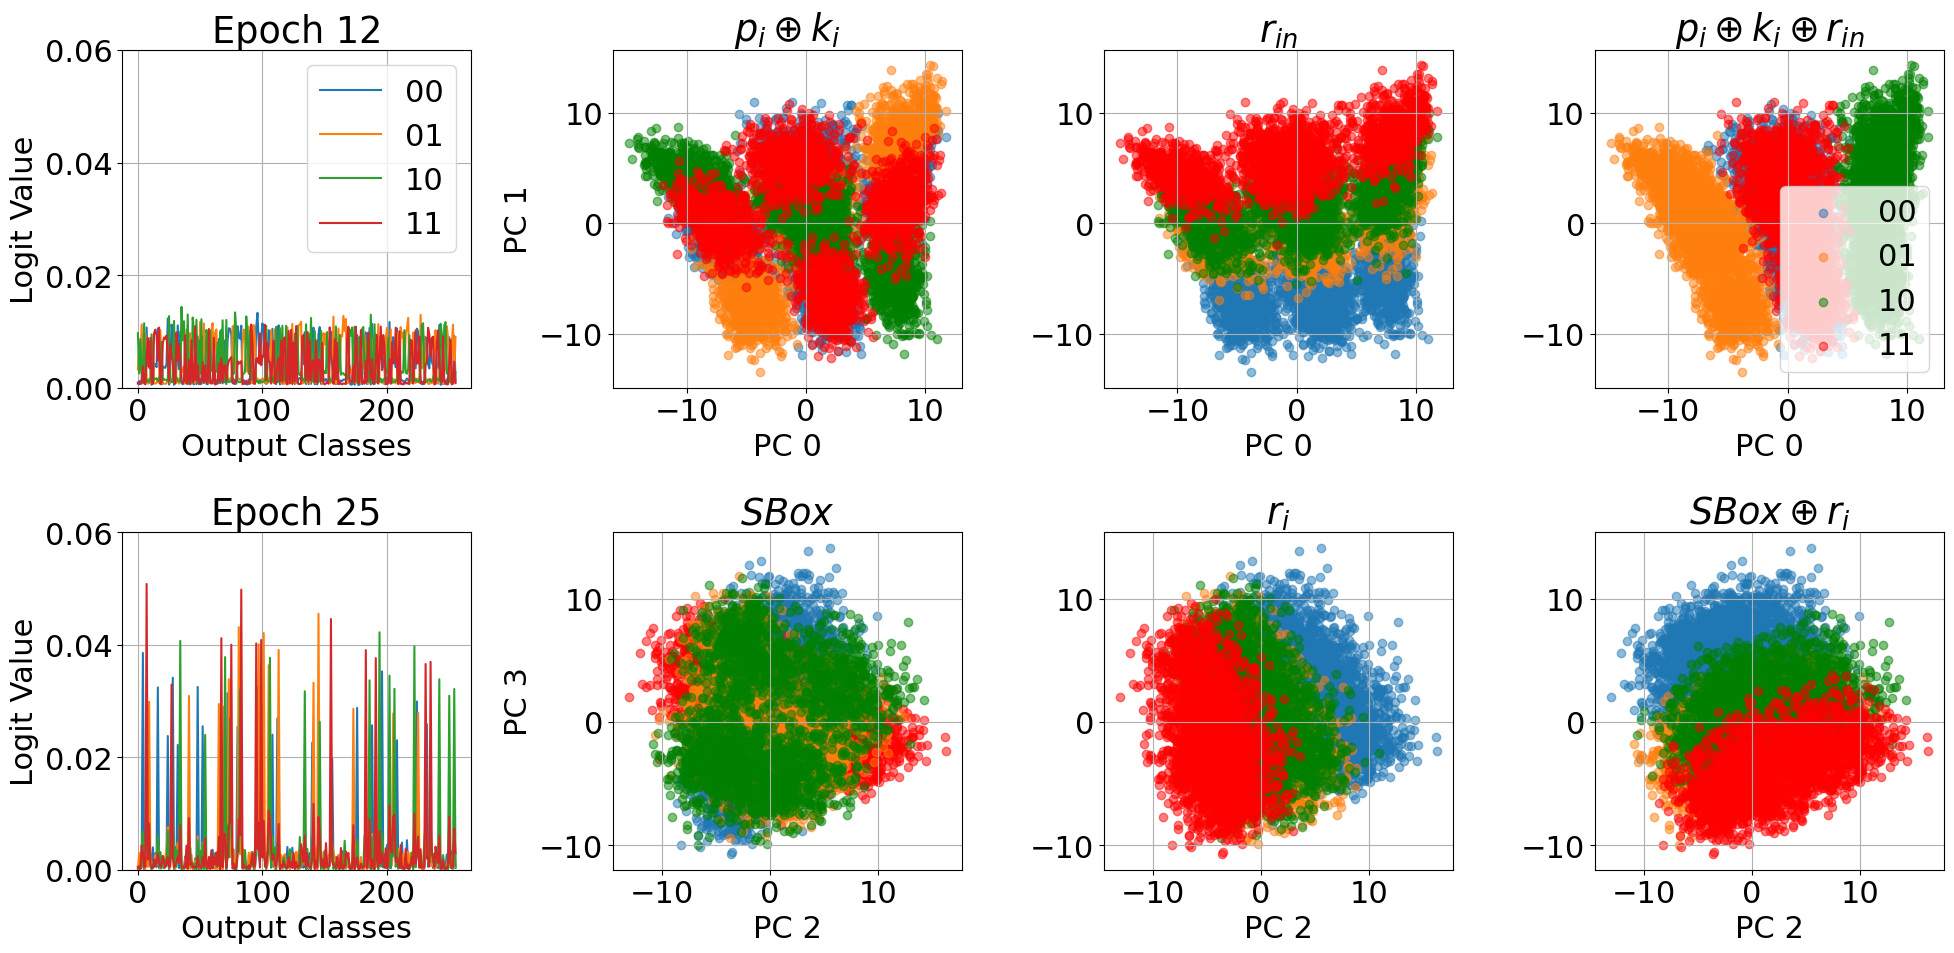

In [17]:
import gc
gc.collect()
reload_model(12)
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^
                dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))
font = {'size'   : 18}
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
#matplotlib.rc('font', **font)
# Prepare logits
out_logits = []

on = np.where(sbox_ins_att&0x3==0)
off = np.where(sbox_ins_att&0x3==1)
on2 = np.where(sbox_ins_att&0x3==2)
off3 = np.where(sbox_ins_att&0x3 ==3)
plt.figure(figsize=(20, 10))  # Adjust the figure size for 1x3 layout

labels = ["00", "01", "10", "11"]
indices_list= [on, off, on2, off3]
# Subplot 1: Logits
plt.subplot(2, 4, 1)
plt.title("Epoch 12")
for i in range(4):
    indices= indices_list[i]
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=labels[i])
plt.ylim([0, 0.06])
plt.grid()
plt.legend()
#plt.title("Logits by HW")
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")

# PCA preparation
comp_n = 4
new_pca = PCA(n_components=comp_n)
layer = 2
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])

# Subplot 2: PC scatter plot for PC2 vs PC1
plt.subplot(2, 4, 2)
in1, in2 = 0, 1

plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.grid()

plt.title("$p_i \oplus k_i$")

# Subplot 3: PC scatter plot for PC1 vs PC0
plt.subplot(2, 4, 3)
rin = dataset.share5_attack[target_byte].astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()
plt.title("$r_{in}$")

plt.subplot(2, 4, 4)
rin = dataset.share6_attack[target_byte].astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()
plt.title("$p_i \oplus k_i \oplus r_{in}$")
plt.legend(loc=4)
#plt.title("PCA Scatter (PC1 vs PC0)")
reload_model(25)

on = np.where(dataset.attack_labels&0x3==0)
off = np.where(dataset.attack_labels&0x3==1)
on2 = np.where(dataset.attack_labels&0x3==2)
off3 = np.where(dataset.attack_labels&0x3 ==3)
labels = ["00", "01", "10", "11"]
indices_list= [on, off, on2, off3]
# Subplot 1: Logits
plt.subplot(2, 4, 5)
plt.title("Epoch 25")
for i in range(4):
    indices= np.intersect1d(indices_list[i], np.where(sbox_ins_att&0x3 == 0)[0])
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=labels[i])
plt.ylim([0, 0.06])
plt.grid()
#plt.legend()
#plt.title("Logits by HW")
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")

# PCA preparation
comp_n = 4
new_pca = PCA(n_components=comp_n)
layer = 2
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])

# Subplot 2: PC scatter plot for PC2 vs PC1
plt.subplot(2, 4, 6)
in1, in2 = 2, 3



plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.grid()

plt.title("$SBox$")

# Subplot 3: PC scatter plot for PC1 vs PC0
plt.subplot(2, 4, 7)
rin = dataset.share1_attack[target_byte].astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()
plt.title("$r_i$")

plt.subplot(2, 4, 8)
rin = dataset.share2_attack[target_byte].astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()
plt.title("$SBox \oplus r_i$")




# Save or show the combined plot
plt.tight_layout()
plt.savefig(f"combined_plots_ascadr_lowest.png", dpi=20)
plt.savefig(f"combined_plots_ascad_lower.png", dpi=100)
plt.savefig(f"combined_plots_ascad.png", dpi=200)
plt.show()

In [ ]:
epoch=25
reload_model(epoch)
layer = 2
from sklearn.manifold import TSNE, Isomap
from sklearn.decomposition import KernelPCA, PCA
pca = PCA(n_components=4)

new_s1_prof = pca.fit_transform(tmp[layer][:100000])
new_s1_att = pca.transform(tmp_att[layer])
on = np.where(dataset.attack_labels&0x3==0)
off = np.where(dataset.attack_labels&0x3==1)
on2 = np.where(dataset.attack_labels&0x3==2)
off3 = np.where(dataset.attack_labels&0x3 ==3)
# on = np.where(sbox_ins_att&0x3==0)
# off = np.where(sbox_ins_att&0x3==1)
# on2 = np.where(sbox_ins_att&0x3==2)
# off3 = np.where(sbox_ins_att&0x3 ==3)
# on = np.where(sbox_ins[:50000]&0x3==0)
# off = np.where(sbox_ins[:50000]&0x3==1)
# on2 = np.where(sbox_ins[:50000]&0x3==2)
# off3 = np.where(sbox_ins[:50000]&0x3 ==3)
# on = np.where(dataset.attack_labels&0x1==0)
# off = np.where(dataset.attack_labels&0x1==1)
# on2 = np.where((dataset.attack_labels>>1)&0x1==0)
# off3 = np.where((dataset.attack_labels>>1)&0x1 ==1)

in1 = 3
in2 = 2


plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
#plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
#plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.legend()
plt.title("Bit 0 & 1 of SBox")
plt.savefig(f"sbox_epoch_{epoch}_ascad.png", dpi=400)
plt.show()
plt.close()
rin = dataset.share1_attack[target_byte].astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)

plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.legend()
plt.title("Bit 0 & 1 of $r_i$")
plt.savefig(f"ri_ascad_epoch_{epoch}.png", dpi=400)
plt.show()
plt.close()
rin = dataset.share2_attack[target_byte].astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)

plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.legend()
plt.title("Bit 0 & 1 of Sbox $\oplus r_i$")
plt.show()
plt.savefig(f"sbox_ri_epoch_{epoch}_ascad.png", dpi=400)
plt.close()

NameError: name 'tmp' is not defined

In [9]:
reduced_indices_00_11 = np.union1d(np.where(sbox_ins&0x3 == 0), np.where(sbox_ins&0x3 == 3))
layer=2
new_pca = PCA(n_components=32)
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
labels = sbox_ins[reduced_indices_00_11] % 2
probe_for_11_00 = train_linear_probe(new_s1_prof[reduced_indices_00_11],labels, epochs=10)



reduced_indices_01_10 = np.union1d(np.where(sbox_ins&0x3 == 1), np.where(sbox_ins&0x3 == 2))

labels = sbox_ins[reduced_indices_01_10] % 2
probe_for_01_10 = train_linear_probe(new_s1_prof[reduced_indices_01_10],labels, epochs=10)

Epoch 1/10
251/251 [==============================] - 1s 3ms/step - loss: 1.3373 - accuracy: 0.5695
Epoch 2/10
251/251 [==============================] - 1s 3ms/step - loss: 0.3819 - accuracy: 0.8346
Epoch 3/10
251/251 [==============================] - 1s 3ms/step - loss: 0.2710 - accuracy: 0.9050
Epoch 4/10
251/251 [==============================] - 1s 3ms/step - loss: 0.2364 - accuracy: 0.9158
Epoch 5/10
251/251 [==============================] - 1s 3ms/step - loss: 0.2186 - accuracy: 0.9193
Epoch 6/10
251/251 [==============================] - 1s 3ms/step - loss: 0.2081 - accuracy: 0.9209
Epoch 7/10
251/251 [==============================] - 1s 3ms/step - loss: 0.2014 - accuracy: 0.9214
Epoch 8/10
251/251 [==============================] - 1s 3ms/step - loss: 0.1972 - accuracy: 0.9219
Epoch 9/10
251/251 [==============================] - 1s 3ms/step - loss: 0.1944 - accuracy: 0.9221
Epoch 10/10
251/251 [==============================] - 1s 3ms/step - loss: 0.1925 - accuracy: 0.9223

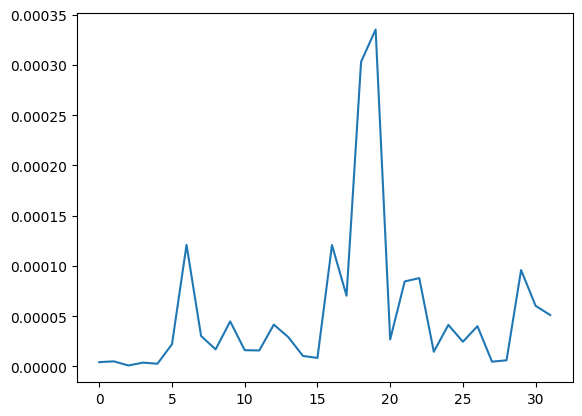

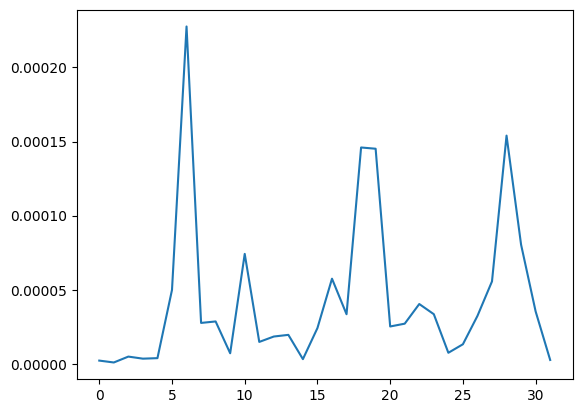

In [10]:
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))
reduced_indices_00_11_att = np.union1d(np.where(sbox_ins_att&0x3 == 0), np.where(sbox_ins_att&0x3 == 3))
in_neurons = tf.Variable(new_s1_att[reduced_indices_00_11_att])
with tf.GradientTape() as tape:
    predicts = probe_for_11_00(in_neurons, training=False)
    loss = tf.keras.losses.CategoricalCrossentropy()(predicts, tf.keras.utils.to_categorical((sbox_ins_att[reduced_indices_00_11_att]&0x1)))

grads = tape.gradient(loss, in_neurons)
dgrad_abs = tf.math.abs(grads)

inf_score = np.average(dgrad_abs.numpy(), axis=0)

#print(inf_score)

plt.plot(inf_score, label=f"Bit")
plt.show()
plt.close()
reduced_indices_10_01_att = np.union1d(np.where(sbox_ins_att&0x3 == 1), np.where(sbox_ins_att&0x3 == 2))
in_neurons = tf.Variable(new_s1_att[reduced_indices_10_01_att])
with tf.GradientTape() as tape:
    predicts = probe_for_01_10(in_neurons, training=False)
    loss = tf.keras.losses.CategoricalCrossentropy()(predicts, tf.keras.utils.to_categorical((sbox_ins_att[reduced_indices_10_01_att]&0x1)))

grads = tape.gradient(loss, in_neurons)
dgrad_abs = tf.math.abs(grads)

inf_score = np.average(dgrad_abs.numpy(), axis=0)

#print(inf_score)

plt.plot(inf_score, label=f"Bit")

In [57]:
epoch = 25
#reload_model(epoch)

in_and_out_lsbs_prof = (sbox_ins &0x3)<<2  ^  dataset.profiling_labels.astype(np.uint8)&0x3
print(in_and_out_lsbs_prof)
in_and_out_lsbs_att = (sbox_ins_att &0x3)<<2 ^ dataset.attack_labels.astype(np.uint8)&0x3
print(tmp[-1].shape)
probe_trained = train_linear_probe(tmp[-2], in_and_out_lsbs_prof, 10)


[13  2  3 ...  1 13  5]
(100000, 256)
Epoch 1/10
500/500 [==============================] - 1s 2ms/step - loss: 1.1657 - accuracy: 0.6248
Epoch 2/10
500/500 [==============================] - 1s 2ms/step - loss: 0.8363 - accuracy: 0.7006
Epoch 3/10
500/500 [==============================] - 1s 2ms/step - loss: 0.8282 - accuracy: 0.7032
Epoch 4/10
500/500 [==============================] - 1s 2ms/step - loss: 0.8244 - accuracy: 0.7043
Epoch 5/10
500/500 [==============================] - 1s 2ms/step - loss: 0.8223 - accuracy: 0.7057
Epoch 6/10
500/500 [==============================] - 1s 2ms/step - loss: 0.8205 - accuracy: 0.7055
Epoch 7/10
500/500 [==============================] - 1s 2ms/step - loss: 0.8193 - accuracy: 0.7061
Epoch 8/10
500/500 [==============================] - 1s 2ms/step - loss: 0.8180 - accuracy: 0.7062
Epoch 9/10
500/500 [==============================] - 1s 2ms/step - loss: 0.8166 - accuracy: 0.7067
Epoch 10/10
500/500 [==============================] - 1s 2ms/

In [58]:
map_out_logits = []
for i in range(16):

     in_sboxes = []
     out_sboxes = []
     for j in range(256):
          if j % 4 == i % 4:
               out_sboxes.append(j)
          if j % 4 == i>>2:
               in_sboxes.append(aes_sbox[j])
     #print(i, np.sort(np.intersect1d(in_sboxes, out_sboxes)))
     map_out_logits.append(np.sort(np.intersect1d(in_sboxes, out_sboxes)))

probe_predicts = probe_trained.predict(tmp_att[-2])
probe_acc = acc = np.sum(np.equal(in_and_out_lsbs_att, np.argmax(probe_predicts, axis=1)))/probe_predicts.shape[0]
print(probe_acc)
transform_probe_predictions = np.zeros((len(tmp_att[-2]), 256))
for i in range(16):
     transform_logits = np.repeat((probe_predicts[:, i]/len(map_out_logits[i])).reshape(-1,1), repeats=len(map_out_logits[i]), axis=1)
     print(transform_logits.shape)
     transform_probe_predictions[:, map_out_logits[i]] += transform_logits.copy()


313/313 [==============================] - 0s 1ms/step
0.6403
(10000, 21)
(10000, 15)
(10000, 16)
(10000, 12)
(10000, 12)
(10000, 20)
(10000, 16)
(10000, 16)
(10000, 17)
(10000, 11)
(10000, 16)
(10000, 20)
(10000, 14)
(10000, 18)
(10000, 16)
(10000, 16)


In [ ]:
from scipy.stats import entropy
print(information(probe_predicts, in_and_out_lsbs_att, 16))
print(information(transform_probe_predictions, dataset.attack_labels, 256))
print(information(model.predict(dataset.x_attack), dataset.attack_labels, 256))

np.average(entropy(transform_probe_predictions, model.predict(dataset.x_attack), base=2,axis=1))

2.490021955847338
2.471311452989979
313/313 [==============================] - 1s 2ms/step
2.5677299865018752
313/313 [==============================] - 0s 1ms/step
-4084.5267155447727
313/313 [==============================] - 0s 1ms/step


0.2263442797218016

In [11]:
acc_per_probe = []
#from tf.keras.metrics import acc
layer_out=2
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))

for i in range(8):
    y_pred = probes_for_bit[i].predict(tmp_att[layer_out])
    y_true = (dataset.attack_labels.astype(np.uint8) >>(i))&0x1
    acc = np.sum(np.equal(y_true, np.argmax(y_pred, axis=1)))/y_true.shape[0]
    print(f"Bit: {i}, acc: {acc}")


for i in range(8):
    y_pred = probes_for_bit[i+8].predict(tmp_att[layer_out])
    y_true = (sbox_ins_att >>(i))&0x1
    acc = np.sum(np.equal(y_true, np.argmax(y_pred, axis=1)))/y_true.shape[0]
    print(f"Bit: {i}, acc: {acc}")



313/313 [==============================] - 0s 1ms/step
Bit: 0, acc: 0.8263
313/313 [==============================] - 0s 1ms/step
Bit: 1, acc: 0.7415
313/313 [==============================] - 0s 1ms/step
Bit: 2, acc: 0.5444
313/313 [==============================] - 0s 1ms/step
Bit: 3, acc: 0.5167


IndexError: list index out of range

In [152]:
#reload_model(25)
layer_out = 5
#print(layer_out, new_s1_att.shape)

probe1 = train_linear_probe(tmp[layer_out], (sbox_ins&0x3), 5)
probe2 = train_linear_probe(tmp[layer_out], ((dataset.profiling_labels)&0x3), 5)
#probe3 = train_linear_probe(tmp[layer_out], ((dataset.profiling_labels>>1)&0x1), 5)
#probe_out = train_linear_probe(tmp[layer_out], dataset.profiling_labels%4, 5)
# print(probe.predict(model_for_probe.predict(pca.inverse_transform(new_s1_att))))
#probe_out = train_linear_probe(model_for_probe.predict(pca.inverse_transform(new_s1_prof)), dataset.profiling_labels%4, 5)
#print(probe.predict(model_for_probe.predict(pca.inverse_transform(new_s1_att))))

Epoch 1/5
500/500 [==============================] - 1s 2ms/step - loss: 0.4816 - accuracy: 0.8242
Epoch 2/5
500/500 [==============================] - 1s 2ms/step - loss: 0.2908 - accuracy: 0.8882
Epoch 3/5
500/500 [==============================] - 1s 2ms/step - loss: 0.2846 - accuracy: 0.8898
Epoch 4/5
500/500 [==============================] - 1s 2ms/step - loss: 0.2829 - accuracy: 0.8901
Epoch 5/5
500/500 [==============================] - 1s 2ms/step - loss: 0.2821 - accuracy: 0.8904
Epoch 1/5
500/500 [==============================] - 1s 2ms/step - loss: 0.8499 - accuracy: 0.6364
Epoch 2/5
500/500 [==============================] - 1s 2ms/step - loss: 0.7120 - accuracy: 0.6982
Epoch 3/5
500/500 [==============================] - 1s 2ms/step - loss: 0.6925 - accuracy: 0.7089
Epoch 4/5
500/500 [==============================] - 1s 2ms/step - loss: 0.6819 - accuracy: 0.7148
Epoch 5/5
500/500 [==============================] - 1s 2ms/step - loss: 0.6751 - accuracy: 0.7182


2 5
313/313 [==============================] - 0s 1ms/step
[[0.65591305 0.0050787  0.00321835 0.33578995]
 [0.62460345 0.00747856 0.00499369 0.36292437]
 [0.6639463  0.00318095 0.00201297 0.33085975]
 ...
 [0.66615635 0.00388355 0.00243303 0.32752705]
 [0.6627814  0.003072   0.0019456  0.33220097]
 [0.6662895  0.00381444 0.00239147 0.32750458]]
313/313 [==============================] - 0s 1ms/step
[[0.52327824 0.01830545 0.01842623 0.4399901 ]
 [0.5196826  0.01731134 0.01763072 0.44537532]
 [0.5418992  0.01337824 0.01076911 0.43395346]
 ...
 [0.52307916 0.01227741 0.0111186  0.45352486]
 [0.51935405 0.01213721 0.01125739 0.45725137]
 [0.50476587 0.01378962 0.01448572 0.4669588 ]]
[0 0 0 ... 0 0 0]
313/313 [==============================] - 0s 962us/step
[[0.12402811 0.403609   0.38708925 0.08527364]
 [0.13187912 0.44186494 0.33134115 0.09491482]
 [0.12892999 0.42994303 0.35038942 0.09073754]
 ...
 [0.11718803 0.33861876 0.4634668  0.08072637]
 [0.12933905 0.4318329  0.34751377 0.09131

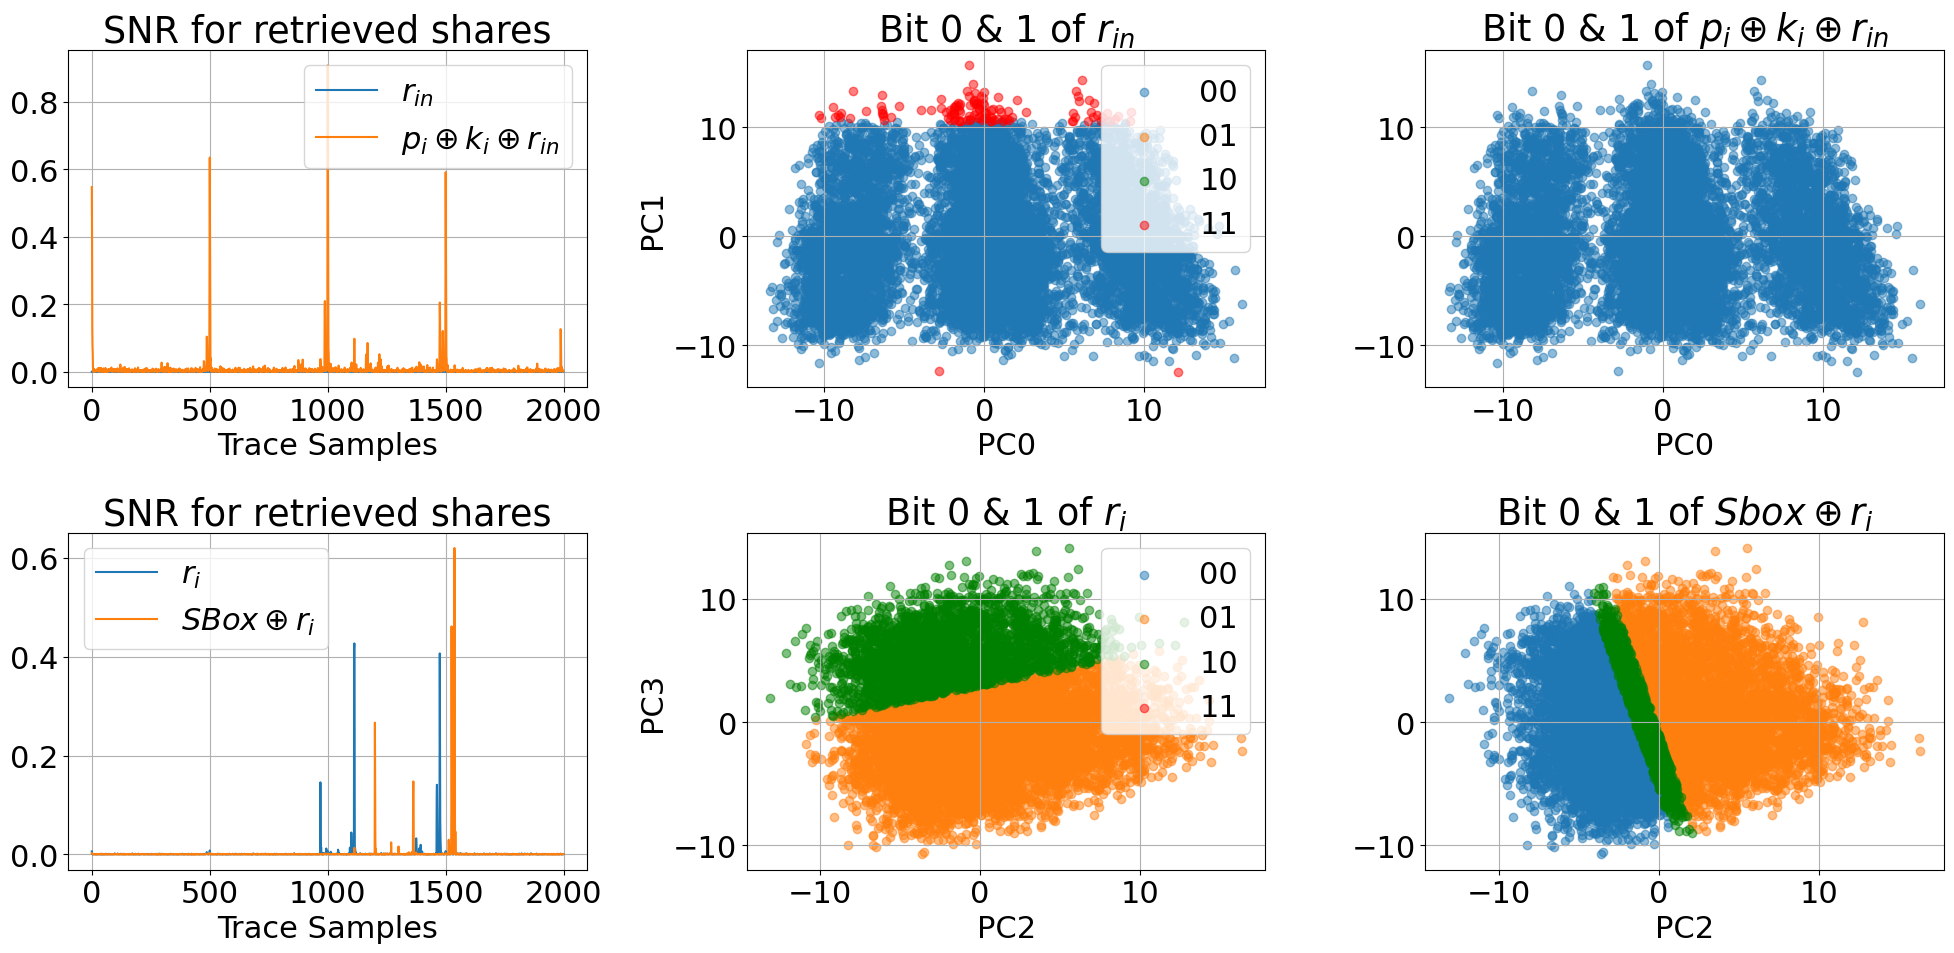

In [178]:

print(layer, layer_out)
plt.figure(figsize=(20, 10))
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
layer=2
model_for_probe =Model(model.layers[layer+1].input, model.layers[layer_out].output)
new_pca = PCA(4)
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
#fix[:, np.where(np.abs(pca.components_[0])> 0.1)[0]] = np.median(fix[np.where(new_s1_att[:, 0] < -5)[0],np.where(np.abs(pca.components_[0])> 0.1)[0]], axis=0)
#new_s1_att[:, 1:3] = fix[:, 1:3] @rot_matrix
fix = new_s1_att.copy()
theta = np.radians(15)  # rotate 180 degrees
rot_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
#new_s1_att[:, 1:3] = fix[:, 1:3] @rot_matrix
#fix[:, 1:3] = fix[:, 1:3] @rot_matrix
fix[:, 0] = 10#12.5
inv_rot =  np.array([[np.cos(-theta), -np.sin(-theta)],
                       [np.sin(-theta), np.cos(-theta)]])
#fix[:, 1:3] = fix[:, 1:3] @inv_rot
#fix[:, 0] = 0
#fix[:, 1] = 10
# print()

fix[:, 3] = 0
fix[:, 2] = 0

patched_preds = probe1.predict(model_for_probe.predict(new_pca.inverse_transform(fix)))
print(patched_preds)
masks_in = np.argmax(patched_preds, axis=1)
fix = new_s1_att.copy()
theta = np.radians(0)  # rotate 180 degrees
rot_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
#new_s1_att[:, 1:3] = fix[:, 1:3] @rot_matrix
#fix[:, 1:3] = fix[:, 1:3] @rot_matrix
fix[:, 1] = -10#12.5
inv_rot =  np.array([[np.cos(-theta), -np.sin(-theta)],
                       [np.sin(-theta), np.cos(-theta)]])
#fix[:, 1:3] = fix[:, 1:3] @inv_rot
#fix[:, 0] = 0
#fix[:, 1] = 10
# print()
# fix[:, 3] = 0
# fix[:, 2] = 0
fix[:, 3] = 0
fix[:, 2] = 0

patched_preds = probe1.predict(model_for_probe.predict(new_pca.inverse_transform(fix)))
print(patched_preds)
masked_in = np.argmax(patched_preds, axis=1) 
#masks_in = np.argmax(probe.predict(tmp_att[layer_out]), axis=1)
print(masks_in)
rin = masks_in.astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
in1=0
in2=1
plt.subplot(2,3,2)
plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.legend()
plt.grid()
plt.title("Bit 0 & 1 of $r_{in}$")
#plt.savefig(f"patched_in_ascad_epoch_{epoch}.png", dpi=400)

rin = masked_in.astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
in1=0
in2=1
plt.subplot(2,3,3)
plt.xlabel(f"PC{in1}")
#plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.grid()
plt.title("Bit 0 & 1 of $p_i \oplus k_i \oplus r_{in}$")
#plt.savefig(f"patched_in_ascad_epoch_{epoch}.png", dpi=400)

plt.subplot(2,3,1)
plt.plot(snr_fast(dataset.x_attack, masked_in), label="$r_{in}$")
plt.plot(snr_fast(dataset.x_attack, masks_in), label="$p_i \oplus k_i \oplus r_{in}$") 
plt.title("SNR for retrieved shares")
plt.xlabel("Trace Samples")
plt.legend()
plt.grid()
layer=2
model_for_probe =Model(model.layers[layer+1].input, model.layers[layer_out].output)
new_pca = PCA(4)
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
#fix[:, np.where(np.abs(pca.components_[0])> 0.1)[0]] = np.median(fix[np.where(new_s1_att[:, 0] < -5)[0],np.where(np.abs(pca.components_[0])> 0.1)[0]], axis=0)
#new_s1_att[:, 1:3] = fix[:, 1:3] @rot_matrix
fix = new_s1_att.copy()
theta = np.radians(15)  # rotate 180 degrees
rot_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
#new_s1_att[:, 1:3] = fix[:, 1:3] @rot_matrix
fix[:, 2:] = fix[:, 2:] @rot_matrix
fix[:, 2] = 12.50#12.5
theta = np.radians(-15) 
inv_rot =  np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
fix[:, 2:] = fix[:, 2:] @inv_rot
fix[:, 0] = 0
fix[:, 1] = 0
# print()

# fix[:, 3] = 0
# fix[:, 2] = 0

patched_preds = probe2.predict(model_for_probe.predict(new_pca.inverse_transform(fix)))
print(patched_preds)
masks_in = np.argmax(patched_preds, axis=1)
fix = new_s1_att.copy()
theta = np.radians(15)  # rotate 180 degrees
rot_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
#new_s1_att[:, 1:3] = fix[:, 1:3] @rot_matrix
fix[:, 2:] = fix[:, 2:] @rot_matrix
fix[:, 3] = -9#12.5
theta = np.radians(-15) 
inv_rot =  np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
fix[:, 2:] = fix[:, 2:] @inv_rot
#fix[:, 0] = 0
#fix[:, 1] = 10
fix[:, 0] = 0
fix[:, 1] = 0
# print()

# fix[:, 3] = 0
# fix[:, 2] = 0

patched_preds = probe2.predict(model_for_probe.predict(new_pca.inverse_transform(fix)))
print(patched_preds)
masked_in = np.argmax(patched_preds, axis=1) 
#masks_in = np.argmax(probe.predict(tmp_att[layer_out]), axis=1)
print(masks_in)
rin = masks_in.astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
in1=2
in2=3
plt.subplot(2,3,5)
plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.legend()
plt.grid()
plt.title("Bit 0 & 1 of $r_{i}$")
#plt.savefig(f"patched_in_ascad_epoch_{epoch}.png", dpi=400)

rin = masked_in.astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
in1=2
in2=3
plt.subplot(2,3,6)
plt.xlabel(f"PC{in1}")
#plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.grid()
plt.title("Bit 0 & 1 of $Sbox\oplus r_{i}$")
#plt.savefig(f"patched_in_ascad_epoch_{epoch}.png", dpi=400)

plt.subplot(2,3,4)
plt.plot(snr_fast(dataset.x_attack, masked_in), label="$r_{i}$")
plt.plot(snr_fast(dataset.x_attack, masks_in), label="$SBox \oplus r_{i}$") 
plt.title("SNR for retrieved shares")
plt.xlabel("Trace Samples")
plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig("patching_in_ascad_same.png", dpi=400)
plt.savefig("patching_in_ascad_lower_same.png", dpi=100)
plt.savefig("patching_in_ascad_lowest_same.png", dpi=50)
plt.show()


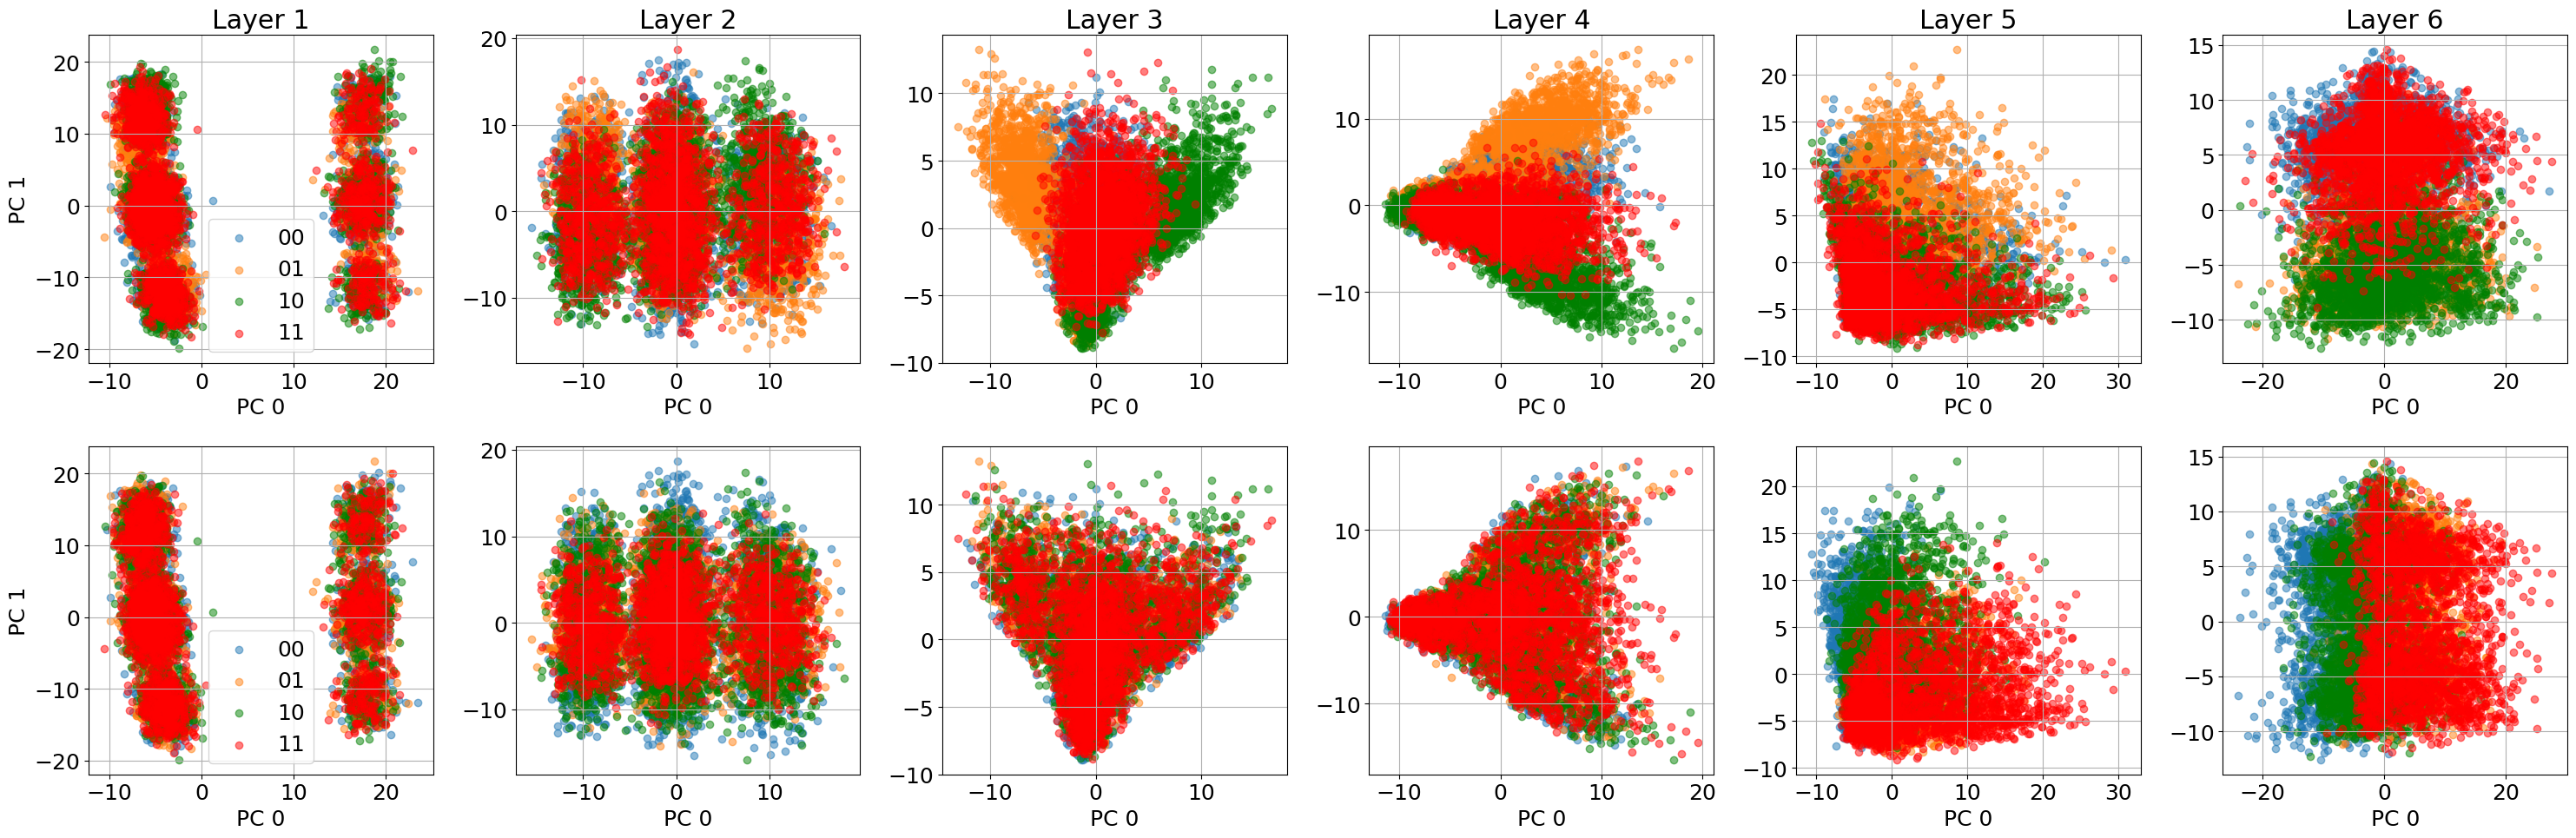

In [12]:
epoch=42
#reload_model(epoch)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 18
#reload_model(epoch)

plt.figure(figsize=(30, 10))
#plt.hspace()
for layer in [1,2,3, 4, 5, 6]:

    comp_n= 4 
    new_pca = PCA(n_components=comp_n)
    #layer=1
    #imp_neurons = np.where(inf_score > np.mean(inf_score))[0]
    #new_s1_prof = new_pca.fit_transform(tmp[layer])
    new_s1_att = new_pca.fit_transform(tmp_att[layer])


    in1 = 0
    in2 = 1
    plt.subplot(2, 6, 6+ layer)
    
    plt.xlabel(f"PC {in1}")
    if layer == 1:
        plt.ylabel(f"PC {in2}")
    #plt.scatter(new_s1_att[:, in1], new_s1_att[:, in2], label="all", alpha=0.1)
    rin = dataset.attack_labels.astype(np.uint8)
    on = np.where(rin&0x3==0)
    off = np.where(rin&0x3==1)
    on2 = np.where(rin&0x3==2)
    off3 = np.where(rin&0x3 ==3)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
    plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
    plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
    plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)

    plt.grid()
    if layer == 1:
        plt.legend(loc=0)
    #plt.legend(loc=1)

    #plt.savefig(f"even_odd_epoch_{epoch}.png", dpi=200)
    plt.subplot(2, 6,layer)
    in1 = 0
    in2 = 1
    plt.xlabel(f"PC {in1}")
    plt.title(f"Layer {layer}")
    if layer == 1:
        plt.ylabel(f"PC {in2}")
    rin = sbox_ins_att.astype(np.uint8)
    on = np.where(rin&0x3==0)
    off = np.where(rin&0x3==1)
    on2 = np.where(rin&0x3==2)
    off3 = np.where(rin&0x3 ==3)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
    plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
    plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
    plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)

    # plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 1], label="KMEANs")
    # #plt.scatter(initialize_arr[:, 2], initialize_arr[:, 1], label="INIT")
    # plt.plot(kmeans.cluster_centers_[sorted_points, 2], kmeans.cluster_centers_[sorted_points, 1])
    plt.grid()
    if layer == 1:
        plt.legend(loc=0)
    #plt.xlim([-1000, 0])
    #plt.savefig(f"even_odd_epoch_{epoch}.png", dpi=200)
plt.tight_layout()
plt.savefig(f"layer_evolution_ascad_{epoch}.png", dpi=200)
plt.show()

313/313 [==============================] - 0s 988us/step
[[6.2989432e-01 1.2155392e-03 6.8875611e-02 3.0001456e-01]
 [7.0546037e-01 5.4424483e-04 4.2551276e-03 2.8974029e-01]
 [9.0532150e-05 9.9985254e-01 2.2955017e-05 3.3920627e-05]
 ...
 [3.8713269e-02 9.1547698e-01 9.8239048e-04 4.4827301e-02]
 [6.6774567e-03 9.8632926e-01 3.2303281e-04 6.6702003e-03]
 [6.0288614e-01 9.6659118e-04 2.7747480e-03 3.9337257e-01]]
313/313 [==============================] - 0s 924us/step
[[3.51382717e-02 9.53428388e-01 2.76342710e-03 8.66989885e-03]
 [4.73494205e-04 9.99242425e-01 1.19436350e-04 1.64713885e-04]
 [6.24853373e-01 2.00625695e-03 8.17438494e-03 3.64966005e-01]
 ...
 [4.02907461e-01 5.02668917e-01 4.23538778e-03 9.01882350e-02]
 [6.34037912e-01 5.72893443e-03 3.49391252e-03 3.56739312e-01]
 [6.60198092e-01 2.19309390e-01 1.13749569e-02 1.09117575e-01]]
[0 0 1 ... 1 1 0]
313/313 [==============================] - 0s 1ms/step
[[0.12402818 0.40360966 0.38708842 0.08527374]
 [0.13187926 0.4418655

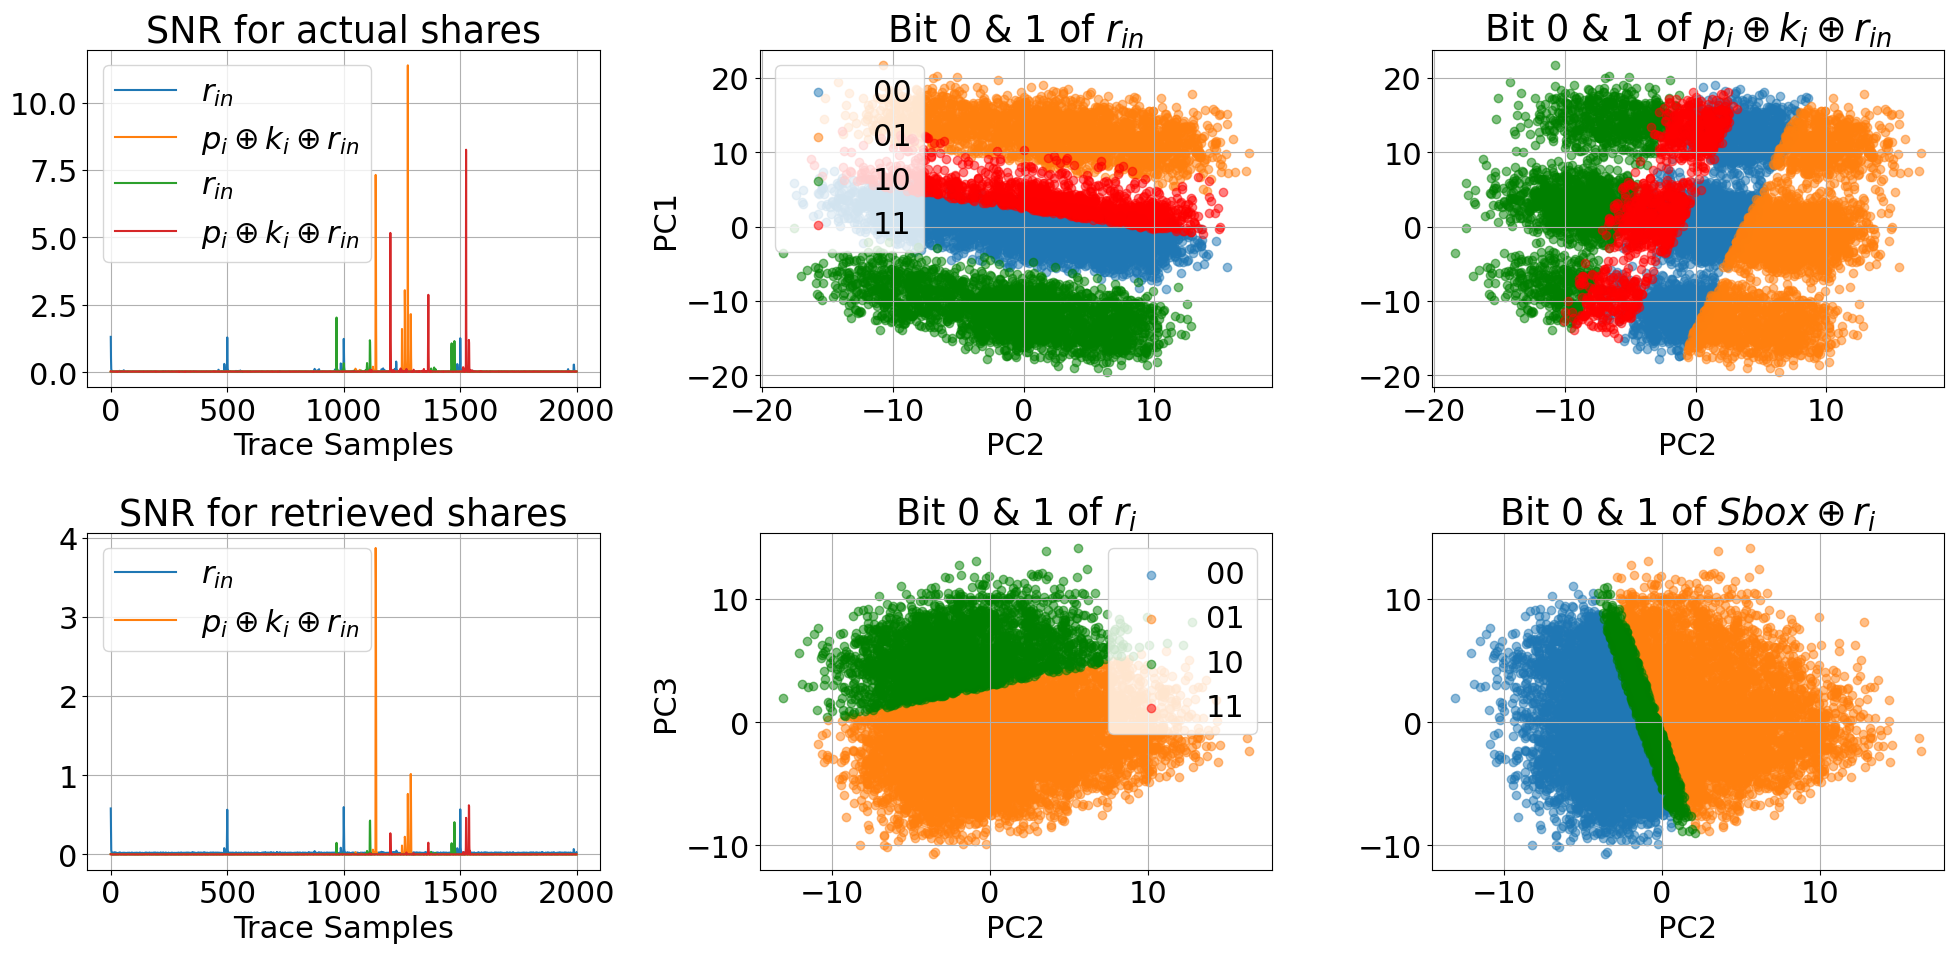

In [181]:
plt.figure(figsize=(20, 10))
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
layer=1
model_for_probe =Model(model.layers[layer+1].input, model.layers[layer_out].output)
new_pca = PCA(3)
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
#fix[:, np.where(np.abs(pca.components_[0])> 0.1)[0]] = np.median(fix[np.where(new_s1_att[:, 0] < -5)[0],np.where(np.abs(pca.components_[0])> 0.1)[0]], axis=0)
#new_s1_att[:, 1:3] = fix[:, 1:3] @rot_matrix
fix = new_s1_att.copy()
theta = np.radians(15)  # rotate 180 degrees
rot_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
#new_s1_att[:, 1:3] = fix[:, 1:3] @rot_matrix
fix[:, 1:3] = fix[:, 1:3] @rot_matrix
fix[:, 2] = 12.50#12.5
inv_rot =  np.array([[np.cos(-theta), -np.sin(-theta)],
                       [np.sin(-theta), np.cos(-theta)]])
fix[:, 1:3] = fix[:, 1:3] @inv_rot
#fix[:, 0] = 0
#fix[:, 1] = 10
# print()

# fix[:, 3] = 0
# fix[:, 2] = 0

patched_preds = probe1.predict(model_for_probe.predict(new_pca.inverse_transform(fix)))
print(patched_preds)
masks_in = np.argmax(patched_preds, axis=1)
fix = new_s1_att.copy()
theta = np.radians(15)  # rotate 180 degrees
rot_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
#new_s1_att[:, 1:3] = fix[:, 1:3] @rot_matrix
fix[:, 1:3] = fix[:, 1:3] @rot_matrix
fix[:, 1] = 12.5#12.5
inv_rot =  np.array([[np.cos(-theta), -np.sin(-theta)],
                       [np.sin(-theta), np.cos(-theta)]])
fix[:, 1:3] = fix[:, 1:3] @inv_rot
#fix[:, 0] = 0
#fix[:, 1] = 10
# print()

# fix[:, 3] = 0
# fix[:, 2] = 0

patched_preds = probe1.predict(model_for_probe.predict(new_pca.inverse_transform(fix)))
print(patched_preds)
masked_in = np.argmax(patched_preds, axis=1) 
#masks_in = np.argmax(probe.predict(tmp_att[layer_out]), axis=1)
print(masks_in)
rin = masks_in.astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
in1=2
in2=1
plt.subplot(2,3,2)
plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.legend()
plt.grid()
plt.title("Bit 0 & 1 of $r_{in}$")
#plt.savefig(f"patched_in_ascad_epoch_{epoch}.png", dpi=400)

rin = masked_in.astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
in1=2
in2=1
plt.subplot(2,3,3)
plt.xlabel(f"PC{in1}")
#plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.grid()
plt.title("Bit 0 & 1 of $p_i \oplus k_i \oplus r_{in}$")
#plt.savefig(f"patched_in_ascad_epoch_{epoch}.png", dpi=400)

plt.subplot(2,3,4)
plt.plot(snr_fast(dataset.x_attack, masked_in), label="$r_{in}$")
plt.plot(snr_fast(dataset.x_attack, masks_in), label="$p_i \oplus k_i \oplus r_{in}$") 
plt.title("SNR for retrieved shares")
plt.xlabel("Trace Samples")
plt.legend()
plt.grid()
layer=2
model_for_probe =Model(model.layers[layer+1].input, model.layers[layer_out].output)
new_pca = PCA(4)
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
#fix[:, np.where(np.abs(pca.components_[0])> 0.1)[0]] = np.median(fix[np.where(new_s1_att[:, 0] < -5)[0],np.where(np.abs(pca.components_[0])> 0.1)[0]], axis=0)
#new_s1_att[:, 1:3] = fix[:, 1:3] @rot_matrix
fix = new_s1_att.copy()
theta = np.radians(15)  # rotate 180 degrees
rot_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
#new_s1_att[:, 1:3] = fix[:, 1:3] @rot_matrix
fix[:, 2:] = fix[:, 2:] @rot_matrix
fix[:, 2] = 12.50#12.5
theta = np.radians(-15) 
inv_rot =  np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
fix[:, 2:] = fix[:, 2:] @inv_rot
fix[:, 0] = 0
fix[:, 1] = 0
# print()

# fix[:, 3] = 0
# fix[:, 2] = 0

patched_preds = probe2.predict(model_for_probe.predict(new_pca.inverse_transform(fix)))
print(patched_preds)
masks_in = np.argmax(patched_preds, axis=1)
fix = new_s1_att.copy()
theta = np.radians(15)  # rotate 180 degrees
rot_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
#new_s1_att[:, 1:3] = fix[:, 1:3] @rot_matrix
fix[:, 2:] = fix[:, 2:] @rot_matrix
fix[:, 3] = -9#12.5
theta = np.radians(-15) 
inv_rot =  np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
fix[:, 2:] = fix[:, 2:] @inv_rot
#fix[:, 0] = 0
#fix[:, 1] = 10
fix[:, 0] = 0
fix[:, 1] = 0
# print()

# fix[:, 3] = 0
# fix[:, 2] = 0

patched_preds = probe2.predict(model_for_probe.predict(new_pca.inverse_transform(fix)))
print(patched_preds)
masked_in = np.argmax(patched_preds, axis=1) 
#masks_in = np.argmax(probe.predict(tmp_att[layer_out]), axis=1)
print(masks_in)

rin = masks_in.astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
in1=2
in2=3
plt.subplot(2,3,5)
plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.legend()
plt.grid()
plt.title("Bit 0 & 1 of $r_{i}$")
#plt.savefig(f"patched_in_ascad_epoch_{epoch}.png", dpi=400)

rin = masked_in.astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
in1=2
in2=3
plt.subplot(2,3,6)
plt.xlabel(f"PC{in1}")
#plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.grid()
plt.title("Bit 0 & 1 of $Sbox\oplus r_{i}$")
#plt.savefig(f"patched_in_ascad_epoch_{epoch}.png", dpi=400)

plt.subplot(2,3,4)
plt.plot(snr_fast(dataset.x_attack, masked_in), label="$r_{i}$")
plt.plot(snr_fast(dataset.x_attack, masks_in), label="$SBox \oplus r_{i}$") 
plt.title("SNR for retrieved shares")
plt.xlabel("Trace Samples")
#plt.legend()
#plt.grid()

plt.subplot(2,3,1)
plt.plot(snr_fast(dataset.x_attack, dataset.share5_attack[target_byte]), label="$r_{in}$")
plt.plot(snr_fast(dataset.x_attack, dataset.share6_attack[target_byte]), label="$p_i \oplus k_i \oplus r_{in}$") 
plt.plot(snr_fast(dataset.x_attack, dataset.share1_attack[target_byte]), label="$r_{in}$")
plt.plot(snr_fast(dataset.x_attack, dataset.share2_attack[target_byte]), label="$p_i \oplus k_i \oplus r_{in}$") 
plt.title("SNR for actual shares")
plt.xlabel("Trace Samples")
plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig("patching_in_ascad.png", dpi=400)
plt.savefig("patching_in_ascad_lower.png", dpi=100)
plt.savefig("patching_in_ascad_lowest.same.png", dpi=50)
plt.show()


2 4
313/313 [==============================] - 0s 1ms/step
[[0.24570988 0.24777485 0.41596317 0.09055213]
 [0.23560087 0.24910961 0.42602664 0.08926285]
 [0.29278517 0.18978956 0.4669873  0.05043799]
 ...
 [0.28997332 0.20028313 0.45523995 0.05450368]
 [0.18075454 0.27707133 0.467636   0.07453804]
 [0.24893185 0.238428   0.43988818 0.07275194]]
[2 2 2 ... 2 2 2]


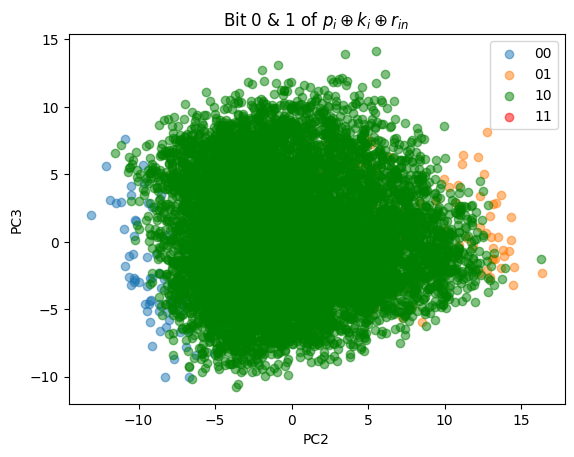

In [144]:
layer=2
model_for_probe =Model(model.layers[layer+1].input, model.layers[layer_out].output)
print(layer, layer_out)
new_pca = PCA(4)
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
fix = tmp_att[layer].copy()
#fix[:, np.where(np.abs(pca.components_[0])> 0.1)[0]] = np.median(fix[np.where(new_s1_att[:, 0] < -5)[0],np.where(np.abs(pca.components_[0])> 0.1)[0]], axis=0)
#new_s1_att[:, 1:3] = fix[:, 1:3] @rot_matrix
fix = new_s1_att.copy()
angle = 15
theta = np.radians(angle)  # rotate 180 degrees
rot_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
#new_s1_att[:, 2:] = new_s1_att[:, 2:] @ rot_matrix
fix[:, 2:] = fix[:, 2:] @rot_matrix
fix[:, 3] = 5#12.5
theta = np.radians(-angle)  # rotate 180 degrees
inv_rot = np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
fix[:, 2:] = fix[:, 2:] @inv_rot
# fix[:, 0] = 0
# fix[:, 1] = 0
# print()

# fix[:, 3] = 0
# fix[:, 2] = 0


patched_preds = probe2.predict(model_for_probe.predict(new_pca.inverse_transform(fix)))
print(patched_preds)
#patched_preds[:, 0] += patched_preds[:, 3] 
masks_in = np.argmax(patched_preds, axis=1)
# patched_preds = probe3.predict(model_for_probe.predict(new_pca.inverse_transform(fix)))
# masks_in += np.argmax(patched_preds, axis=1)*2
#masks_in = np.argmax(probe.predict(tmp_att[layer_out]), axis=1)
print(masks_in)
rin = masks_in.astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
in1=2
in2=3
plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.legend()
plt.title("Bit 0 & 1 of $p_i \oplus k_i \oplus r_{in}$")
#plt.savefig(f"patched_in_ascad_epoch_{epoch}.png", dpi=400)
plt.show()
plt.close() 

[2.47183585e+00 1.16094112e+00 2.67446852e+00 2.19065323e-01
 8.43754053e-01 3.62027049e-01 2.41467619e+00 3.74546218e+00
 1.12427242e-01 2.90805602e+00 1.23537035e+01 2.87126589e+00
 2.83110452e+00 3.60313296e+00 3.02237201e+00 7.50561416e-01
 7.98450053e-01 4.25138235e+00 2.26032585e-01 2.32304883e+00
 9.85223413e-01 3.87346298e-01 2.22901273e+00 2.43011420e-03
 5.76488066e+00 2.20022179e-04 2.17373803e-01 1.49040663e+00
 4.57243761e-04 2.68278271e-01 6.46995604e-01 2.87586379e+00
 1.26107037e+00 1.08801119e-01 4.98376369e-01 6.62638903e-01
 1.47289168e-02 2.26361179e+00 2.22781157e+00 1.94035506e+00
 1.89329058e-01 5.88378251e-01 6.33561984e-02 2.85814628e-02
 2.45119572e-01 3.50900745e+00 1.18134189e+00 1.23674738e+00
 2.68830284e-02 1.48574816e-06 2.46556783e+00 1.85521439e-01
 1.31434649e-01 2.31047086e-02 3.55757332e+00 2.90452147e+00
 1.15547335e+00 2.76508164e+00 2.62592411e+00 2.75713897e+00
 2.21332181e-02 1.30467768e+01 3.27382731e+00 3.25855315e-02
 5.47778487e-01 1.603779

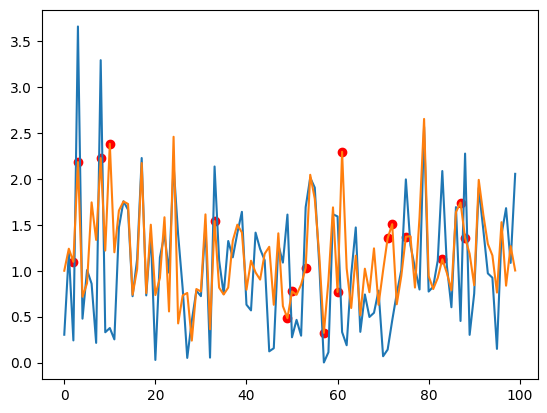

[0]


In [ ]:

plt.plot(np.std(tmp_att[layer][np.where(new_s1_att[:, 0] < -5)[0]], axis=0))
var_hi =np.std(tmp_att[layer][np.where(np.abs(new_s1_att[:, 0]) < 5)[0]], axis=0)
plt.plot(var_hi)
print(np.var(tmp_att[layer][np.where((new_s1_att[:, 0]) >5)[0]], axis=0))
plt.scatter(, var_hi[np.where(np.abs(pca.components_[0])> 0.1)[0]],color='r')
plt.show()
print([0])


In [ ]:

matrix = np.zeros((16, 8))
matrix_in = np.zeros((16, 8))
for i in range(256):
    for bit in range(8):
        matrix[(i) %4 + (aes_sbox[i]%4)*4, bit] += (aes_sbox[i]>>bit) &0x1
        matrix_in[((i) %4)*4 + (aes_sbox[i]%4), bit] += (i>>bit) &0x1

print(matrix)
print(matrix_in)
out_bit = 0
indices_00, = np.where((dataset.attack_labels) % 2 == out_bit)
for pred_bit in range(2,8):
#pred_bit = 4

    print(1, pred_bit, matrix[1, pred_bit], np.sum((np.argmax(outs[pred_bit],axis=1))))
    print(2, pred_bit, matrix[0, pred_bit], np.sum((np.argmax(outs2[pred_bit],axis=1))))


[[ 0.  0.  9.  8. 11. 11. 10.  8.]
 [ 0.  0.  8.  9.  8.  6.  9.  6.]
 [ 0.  0.  8.  7.  8. 10.  6.  8.]
 [ 0.  0.  7.  8.  5.  5.  7. 10.]
 [15.  0.  5.  7.  3.  7. 10.  5.]
 [20.  0. 11. 10. 14.  6. 11. 14.]
 [11.  0.  6.  5.  5.  6.  2.  5.]
 [18.  0. 10. 10. 10. 13.  9.  8.]
 [ 0. 16.  6.  8.  8.  7. 11. 10.]
 [ 0. 16. 11.  7.  9.  9.  6.  6.]
 [ 0. 16.  7.  9.  9.  9.  8.  9.]
 [ 0. 16.  8.  8.  6.  7.  7.  7.]
 [12. 12.  5.  6.  6.  5.  7.  5.]
 [16. 16.  8.  6.  6.  9.  8. 11.]
 [20. 20. 11.  8. 10. 11.  8.  8.]
 [16. 16.  8. 12. 10.  7.  9.  8.]]
[[ 0.  0.  9. 11. 12. 11. 11. 11.]
 [ 0.  0.  7.  8.  6. 10.  8.  9.]
 [ 0.  0. 10.  9.  9.  4.  7.  7.]
 [ 0.  0.  6.  4.  5.  7.  6.  5.]
 [12.  0.  6.  6.  6.  5.  6.  5.]
 [20.  0. 10. 11.  9. 11. 12. 12.]
 [16.  0.  8.  7. 11.  9.  6. 11.]
 [16.  0.  8.  8.  6.  7.  8.  4.]
 [ 0. 17.  8.  8.  8.  9.  9. 11.]
 [ 0. 11.  5.  5.  7.  5.  6.  6.]
 [ 0. 16.  8.  9.  9.  9.  9.  7.]
 [ 0. 20. 11. 10.  8.  9.  8.  8.]
 [14. 14. 11.  5.  

21/21 [==============================] - 0s 1ms/step


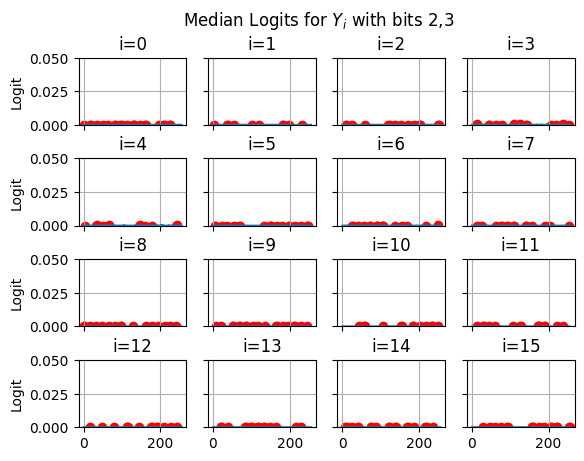

[array([8.23520077e-06, 2.90897115e-05, 1.04035062e-05, 3.63345571e-05,
       3.95305906e-05, 1.24531989e-05, 2.78644839e-05, 1.14816990e-04,
       1.47909650e-05, 1.15317416e-04, 2.71887075e-05, 1.69498089e-05,
       9.60816396e-05, 1.63726581e-05, 2.31839658e-05, 1.15848798e-05,
       3.87891378e-05, 9.95605296e-06, 3.08547824e-05, 2.17132019e-05,
       1.32594623e-05, 9.74142586e-06, 1.19851993e-05, 3.52091629e-05,
       3.89877459e-05, 2.10793078e-05, 3.34558245e-05, 7.87172758e-05,
       5.04729178e-05, 1.44776059e-05, 3.07696027e-05, 1.50587994e-05,
       2.93924986e-05, 1.04887895e-05, 4.52702734e-05, 1.87167389e-05,
       9.22778599e-06, 1.16655792e-05, 1.70976928e-05, 4.16595358e-05,
       8.73147110e-06, 1.32866844e-04, 3.73742223e-05, 2.01180937e-05,
       1.16565916e-05, 2.24922242e-05, 1.99336864e-05, 1.08308232e-05,
       3.31050105e-05, 1.36901526e-05, 2.30221285e-05, 2.06893783e-05,
       5.01572649e-05, 3.23771637e-05, 5.75144877e-05, 3.13131168e-05,
     

In [10]:
out_logits = []
epoch = 25
#reload_model(epoch)
fig, axs =plt.subplots(4,4)
fig.subplots_adjust(hspace=0.5)
for i in range(16):
    indices, =np.where(((dataset.attack_labels.astype(np.uint8)>>2) %4 == i %4))
    indices_other, = np.where((sbox_ins_att>>2)  % 4 == (i >>2) %4)
    final_indices = np.intersect1d(indices, indices_other)
    #print(final_indices)
    logits = model.predict(dataset.x_attack[final_indices])
    out_logits.append(np.median(logits, axis=0))
    #out_logits.append(logits[9])
    axs[i//4, i%4].set_title(f"i={i}")
    axs[i//4, i%4].plot(out_logits[i], label="Median Logits")
    axs[i//4, i%4].grid()
    axs[i//4, i%4].set_ylim([0, 0.05])
    axs[i//4, i%4].scatter(list_of_stuffs[i], out_logits[-1][list_of_stuffs[i]], label=f"Points $Y_{i}$", color='r')
    


for ax in axs.flat:
    ax.set(ylabel='Logit')
    # Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()
fig.suptitle(f"Median Logits for $Y_i$ with bits 2,3")
plt.savefig(f"varying_logits_ASCAD_epoch_{epoch}_wrong_bits.png", dpi=200)
plt.show()

print(out_logits)


78/78 [==============================] - 0s 1ms/step


78/78 [==============================] - 0s 1ms/step


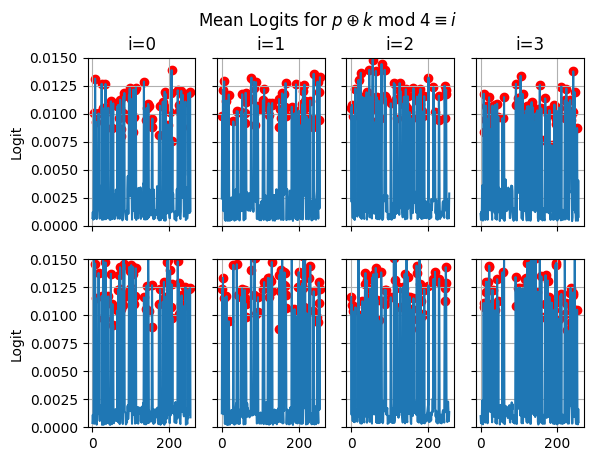

[array([0.00068506, 0.00121589, 0.0005389 , 0.00135714, 0.01006797,
       0.00060876, 0.00134436, 0.01313152, 0.00382065, 0.00925579,
       0.0024298 , 0.00058688, 0.00133742, 0.00303961, 0.00309921,
       0.00268677, 0.0100223 , 0.00304329, 0.00131208, 0.00062831,
       0.00355734, 0.00301503, 0.00284147, 0.00292764, 0.01266062,
       0.00052464, 0.00294802, 0.01049435, 0.01010149, 0.00054814,
       0.00108252, 0.00307152, 0.01007891, 0.00268308, 0.01265215,
       0.00057895, 0.0007345 , 0.00071224, 0.00330401, 0.00111507,
       0.00067142, 0.01051477, 0.00124108, 0.00291651, 0.00078006,
       0.00054668, 0.00250244, 0.00053521, 0.01110127, 0.00058362,
       0.00118546, 0.00060239, 0.0087272 , 0.00112764, 0.0109247 ,
       0.00063585, 0.0006839 , 0.00281809, 0.0005915 , 0.00094386,
       0.00105822, 0.00321996, 0.00115451, 0.00134035, 0.00091323,
       0.01066517, 0.00063686, 0.01078219, 0.00080476, 0.00959754,
       0.01076588, 0.00061783, 0.01124743, 0.01050008, 0.0086

In [ ]:
out_logits = []
fig, axs =plt.subplots(2,4)
#fig.subplots_adjust(hspace=0.5)
only_reload(12)
for i in range(8):
    indices_logit_hl = []
    for j in range(256):
        if j %4 == i %4:
            indices_logit_hl.append(aes_sbox[j])

    #indices, =np.where((dataset.attack_labels %4 == i %4))
    if i ==4:
        only_reload(25)
    indices_other, = np.where(sbox_ins_att  % 4 == (i) %4)
    #final_indices = np.intersect1d(indices, indices_other)
    #print(final_indices)
    logits = model.predict(dataset.x_attack[indices_other])
    out_logits.append(np.median(logits, axis=0))
    #out_logits.append(logits[9])
    if i < 4:
        axs[i//4,i%4].set_title(f"i={i}")
    
    axs[i//4, i%4].plot(out_logits[-1], label="Median Logits")
    axs[i//4, i%4].grid()
    axs[i//4, i%4].set_ylim([0, 0.015])
    axs[i//4, i%4].scatter(indices_logit_hl, out_logits[-1][indices_logit_hl], color='r')
    


for ax in axs.flat:
    ax.set(ylabel='Logit')
    # Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()
fig.suptitle(f"Median Logits for $p \oplus k$ mod $4 \equiv i$")
plt.savefig(f"varying_logits_ASCAD_epoch_12_15.png", dpi=200)
plt.show()

print(out_logits)

In [8]:
list_of_stuffs = []
for i in range(16):
     #ins, = np.where(out_logits[i] > 0.005)
    # print(i, ins)
     in_sboxes = []
     out_sboxes = []
     for j in range(256):
          if (j>>2) % 4 == (i>>2):
               in_sboxes.append(aes_sbox[j])
          if (j>>2) % 4 == i %4:
               out_sboxes.append(j)
     list_of_stuffs.append(np.sort(np.intersect1d(in_sboxes, out_sboxes)))
     #print(i, np.sort(np.intersect1d(in_sboxes, out_sboxes)))
#np.argsort(out_logits[1])[::-1]
#np.argsort(out_logits[2])[::-1]


2/2 [==============================] - 0s 3ms/step
2 [  2  58  66  78  90 114 126 142 162 170 174 178 190 214 218 246]
2/2 [==============================] - 0s 2ms/step


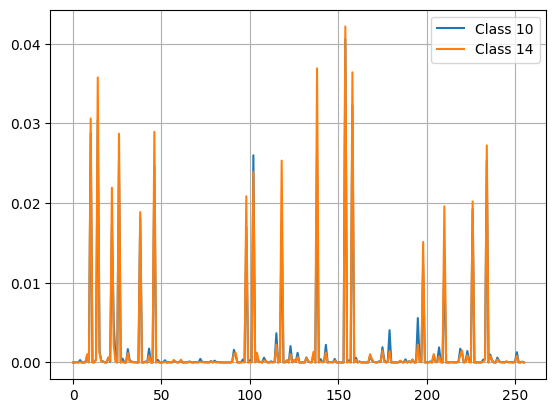

In [11]:
epoch= 25
only_reload(epoch)
out_logits = []
i = 2
indices, =np.where((dataset.attack_labels == i))

logits = model.predict(dataset.x_attack[indices])
out_logits.append(np.median(logits, axis=0))
#out_logits.append(logits[9])
similar_indices = np.where(out_logits[-1] > 0.002)[0]
print(i, np.where(out_logits[-1] > 0.002)[0])
for i in [10, 14]:
    indices, =np.where((dataset.attack_labels == i))

    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.median(logits, axis=0))
    plt.plot(out_logits[-1], label=f"Class {i}")
plt.grid()
plt.legend()
plt.savefig(f"logits_ascad_epoch_{epoch}.png", dpi=400)
plt.show()
#print(out_logits)